# Restaurant Success Analysis
**Yelp Dataset · User Engagement & Business Metrics**


## Problem Statement

In a competitive market like the restaurant industry, understanding the factors that influence business success is crucial for stakeholders. Utilizing the Yelp dataset, this project investigates the relationship between user engagement (reviews, tips, and check-ins) and business success metrics (review count, ratings) for restaurants.


## Research Objectives

1. Quantify the correlation between user engagement (reviews, tips, check-ins) and review count / average star rating.
2. Analyse the impact of review sentiment on restaurant ratings — using NLP scoring on actual review text.
3. Explore whether consistent engagement over time is associated with sustained business success.


## Hypotheses

- **H1:** Higher levels of user engagement (more reviews, tips, and check-ins) correlate with higher review counts and ratings.
- **H2:** Positive sentiment in review text is associated with higher star ratings.
- **H3:** Successful restaurants (high ratings) exhibit consistent and growing user engagement over time.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
from datetime import datetime
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')

colors = ['#FFF1E5', '#F8862C', '#CB754B']
custom_cmap = LinearSegmentedColormap.from_list('mycmap', colors)


## Database Connection


In [2]:
conn = sqlite3.connect('yelp.db')

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables


,name
0,business
1,review
2,user
3,tip
4,checkin


## Schema Exploration

Before any analysis, let's understand what columns and data types are available in each table.


In [3]:
for table in tables['name']:
    print('-'*50, f'{table}', '-'*50)
    display(pd.read_sql_query(f'SELECT * FROM {table} LIMIT 5', conn))


-------------------------------------------------- business --------------------------------------------------


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"Brewpubs, Breweries, Food"


-------------------------------------------------- review --------------------------------------------------


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


-------------------------------------------------- user --------------------------------------------------


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


-------------------------------------------------- tip --------------------------------------------------


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


-------------------------------------------------- checkin --------------------------------------------------


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


**Observations from the schema:**

- `business` — contains name, location (city, state, lat/lon), categories, star rating, review count, and whether the business is open.
- `review` — individual reviews with star rating, date, text, and social reaction votes (useful, funny, cool).
- `tip` — short tips left by users, with date and business reference.
- `checkin` — a single comma-separated string of all check-in timestamps per business. Needs parsing before use.
- `user` — user profiles including review count and elite status.

The `checkin.date` column stores all timestamps as one comma-separated string per business row. We will need to handle this carefully when computing check-in counts rather than relying on SQL string tricks.


## Exploratory Data Analysis


In [4]:
# How many businesses are in the dataset?
pd.read_sql_query('SELECT COUNT(*) AS Total_Businesses FROM business', conn)


,Total_Businesses
0,150346


The business table contains all business types — not just restaurants. Let's narrow down to what we care about: open restaurants.


In [5]:
# Filter to open restaurants only
query = """
    SELECT business_id, review_count
    FROM   business
    WHERE  LOWER(categories) LIKE '%restaurant%'
      AND  is_open = 1
"""
business_id = pd.read_sql_query(query, conn)
print(f'Open restaurants found: {len(business_id):,}')
business_id.head()


Open restaurants found: 35,004


,business_id,review_count
0,MTSW4McQd7CbVtyjqoe9mw,80
1,CF33F8-E6oudUQ46HnavjQ,6
2,bBDDEgkFA1Otx9Lfe7BZUQ,10
3,eEOYSgkmpB90uNA7lDOMRA,10
4,il_Ro8jwPlHresjw9EGmBg,28


We're now working with open restaurants only. Before jumping into analysis, let's look at the distribution of review counts and star ratings across these restaurants.


In [6]:
# Descriptive stats for review count and star rating
query = f"""
    SELECT
        AVG(review_count)    AS average_review_count,
        MIN(review_count)    AS min_review_count,
        MAX(review_count)    AS max_review_count,
        (SELECT review_count FROM business
         ORDER BY review_count
         LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_review_count,
        AVG(stars)           AS average_star_rating,
        MIN(stars)           AS min_star_rating,
        MAX(stars)           AS max_star_rating,
        (SELECT stars FROM business
         ORDER BY stars
         LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_star_rating
    FROM business
    WHERE business_id IN {tuple(business_id['business_id'])}
"""
pd.read_sql_query(query, conn).transpose()


,0
average_review_count,104.097789
min_review_count,5.000000
max_review_count,7568.000000
median_review_count,15.000000
average_star_rating,3.523969
min_star_rating,1.000000
max_star_rating,5.000000
median_star_rating,3.500000


The median review count (15) is far below the mean (104), and the max reaches 7,568. This kind of right-skewed distribution means a handful of very popular restaurants would dominate any aggregate analysis. We'll remove these outliers using the IQR method before proceeding.


In [7]:
def remove_outliers(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Remove rows where col falls outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    return df[(df[col] >= q1 - 1.5 * iqr) & (df[col] <= q3 + 1.5 * iqr)]

business_id = remove_outliers(business_id, 'review_count')
print(f'Restaurants retained after outlier removal: {len(business_id):,}')


Restaurants retained after outlier removal: 31,537


In [8]:
# Check how the distribution looks after removal
query = f"""
    SELECT
        AVG(review_count)    AS average_review_count,
        MIN(review_count)    AS min_review_count,
        MAX(review_count)    AS max_review_count,
        (SELECT review_count FROM business
         ORDER BY review_count
         LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_review_count,
        AVG(stars)           AS average_star_rating,
        MIN(stars)           AS min_star_rating,
        MAX(stars)           AS max_star_rating,
        (SELECT stars FROM business
         ORDER BY stars
         LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_star_rating
    FROM business
    WHERE business_id IN {tuple(business_id['business_id'])}
"""
pd.read_sql_query(query, conn).transpose()


,0
average_review_count,55.975426
min_review_count,5.000000
max_review_count,248.000000
median_review_count,15.000000
average_star_rating,3.477281
min_star_rating,1.000000
max_star_rating,5.000000
median_star_rating,3.500000


Average review count dropped from 104 to 55, and the max is now 248 — a much more representative picture. With the dataset cleaned, let's start exploring.


In [9]:
# Which restaurants have the highest number of reviews?
query = f"""
    SELECT name, SUM(review_count) AS review_count, AVG(stars) AS avg_rating
    FROM   business
    WHERE  business_id IN {tuple(business_id['business_id'])}
    GROUP  BY name
    ORDER  BY review_count DESC
    LIMIT  10
"""
pd.read_sql_query(query, conn)


,name,review_count,avg_rating
0,McDonald's,16490,1.868702
1,Chipotle Mexican Grill,9071,2.381757
2,Taco Bell,8017,2.141813
3,Chick-fil-A,7687,3.377419
4,First Watch,6761,3.875000
5,Panera Bread,6613,2.661905
6,Buffalo Wild Wings,6483,2.344828
7,Domino's Pizza,6091,2.290210
8,Wendy's,5930,2.030159
9,Chili's,5744,2.514706


In [10]:
# Which restaurants have the highest rating?
query = f"""
    SELECT name, SUM(review_count) AS review_count, AVG(stars) AS avg_rating
    FROM   business
    WHERE  business_id IN {tuple(business_id['business_id'])}
    GROUP  BY name
    ORDER  BY avg_rating DESC
    LIMIT  10
"""
pd.read_sql_query(query, conn)


,name,review_count,avg_rating
0,ā café,48,5.0
1,two birds cafe,77,5.0
2,the brewers cabinet production,13,5.0
3,taqueria la cañada,17,5.0
4,la bamba,44,5.0
5,la 5th av tacos,24,5.0
6,el sabor mexican and chinese food,21,5.0
7,eat.drink.Om...YOGA CAFE,7,5.0
8,d4 Tabletop Gaming Cafe,8,5.0
9,cabbage vegetarian cafe,12,5.0


Two different pictures emerge immediately:

- The most-reviewed restaurants are large chains (McDonald's, Taco Bell) with fairly mediocre ratings (1.5–2.5★).
- The highest-rated restaurants have very few reviews — mostly niche or independent spots.

This tells us that **review count and star rating are capturing different dimensions of a restaurant's presence**. A restaurant can be popular without being well-regarded, and vice versa. Neither metric alone is a good definition of 'success' — which motivates building a composite metric later.


## Does Higher Engagement Translate to Higher Ratings?

Let's see whether restaurants with more reviews, tips, and check-ins also tend to have better ratings.


In [11]:
query = f"""
    SELECT
        total.avg_rating AS rating,
        AVG(total.review_count)  AS avg_review_count,
        AVG(total.checkin_count) AS avg_checkin_count,
        AVG(total.tip_count)     AS avg_tip_count
    FROM (
        SELECT
            b.business_id,
            SUM(b.review_count)                                                          AS review_count,
            AVG(b.stars)                                                                 AS avg_rating,
            SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1)                AS checkin_count,
            SUM(tip.tip_count)                                                           AS tip_count
        FROM business b
        LEFT JOIN checkin cc ON b.business_id = cc.business_id
        LEFT JOIN (
            SELECT business_id, COUNT(business_id) AS tip_count
            FROM   tip GROUP BY business_id
        ) AS tip ON b.business_id = tip.business_id
        WHERE b.business_id IN {tuple(business_id['business_id'])}
        GROUP BY b.business_id
    ) AS total
    GROUP BY total.avg_rating
"""
review_count_df = pd.read_sql_query(query, conn)
display(review_count_df)


,rating,avg_review_count,avg_checkin_count,avg_tip_count
0,1.0,14.365079,17.518072,2.781513
1,1.5,24.358459,34.480969,3.884654
2,2.0,27.759629,52.386515,4.581058
3,2.5,36.631037,79.349429,6.325225
4,3.0,48.054998,105.970405,8.301950
5,3.5,63.730125,125.781702,10.320786
6,4.0,73.136954,127.139075,11.329362
7,4.5,65.282554,86.177605,8.995201
8,5.0,31.127979,27.545113,4.269082


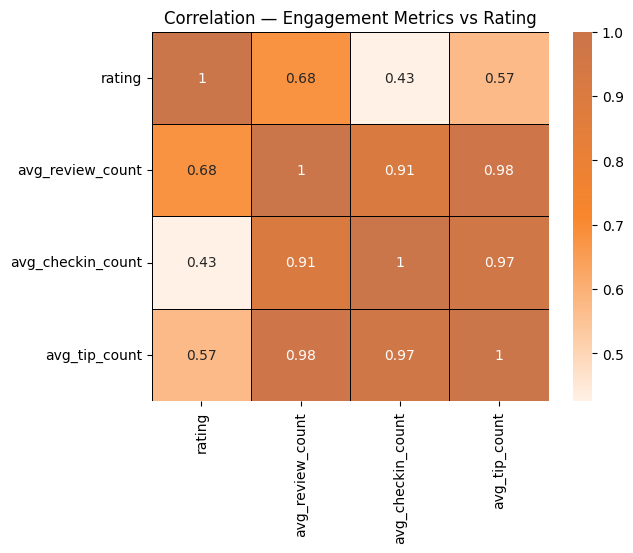

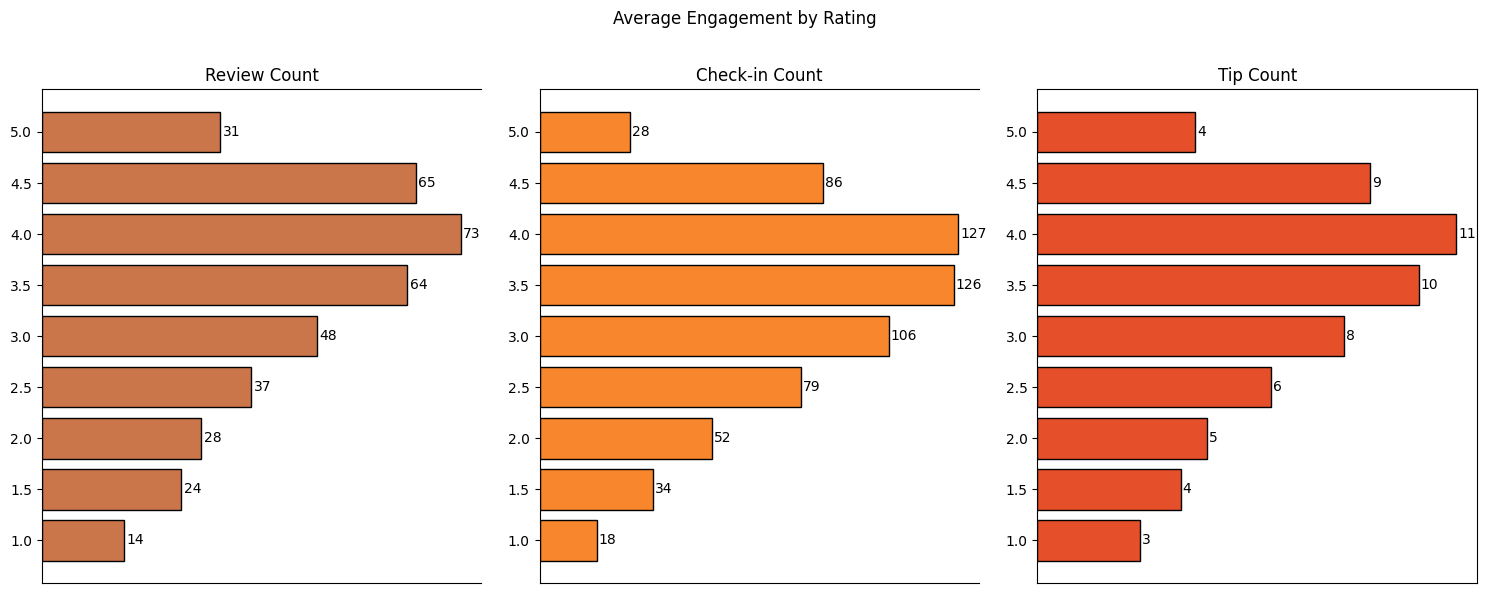

In [12]:
sns.heatmap(review_count_df.corr(), cmap=custom_cmap, annot=True, linewidth=0.5, linecolor='black')
plt.title('Correlation — Engagement Metrics vs Rating')
plt.show()

plt.figure(figsize=(15, 6))
plt.suptitle('Average Engagement by Rating\n')

plt.subplot(1, 3, 1)
plt.title('Review Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_review_count'],
         edgecolor='k', color='#CB754B')
plt.gca().spines['right'].set_visible(False)
for i, v in enumerate(review_count_df['avg_review_count']):
    plt.text(v + 0.5, i, str(round(v)), va='center')
plt.xticks([])

plt.subplot(1, 3, 2)
plt.title('Check-in Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_checkin_count'],
         edgecolor='k', color='#F8862C')
plt.gca().spines['right'].set_visible(False)
for i, v in enumerate(review_count_df['avg_checkin_count']):
    plt.text(v + 0.5, i, str(round(v)), va='center')
plt.xticks([])

plt.subplot(1, 3, 3)
plt.title('Tip Count')
plt.barh(review_count_df['rating'].astype('str'), review_count_df['avg_tip_count'],
         edgecolor='k', color='#E54F29')
for i, v in enumerate(review_count_df['avg_tip_count']):
    plt.text(v + 0.05, i, str(round(v)), va='center')
plt.xticks([])

plt.tight_layout()
plt.show()


This is interesting. Engagement consistently rises from 1★ through to 4★, but then drops noticeably at 4.5★ and falls sharply at 5★. A few possible explanations:

- 5★ restaurants may be very niche or new — not yet widely discovered.
- There could be a ceiling effect: a small, loyal customer base that doesn't need to review repeatedly.
- Extreme ratings (1★ or 5★) may reflect fewer, more emotionally motivated reviews rather than broad everyday engagement.

What's clear is that the relationship isn't linear — it peaks around 4★. This suggests that restaurants around 4★ hit a sweet spot of quality that drives broad engagement. Going forward, we'll treat restaurants above 3.5★ as 'high-rated' and below as 'low-rated' — this split naturally falls just below where the engagement peak begins.


## Correlation Between Engagement Metrics

Now let's look at how the engagement signals (reviews, tips, check-ins) relate to each other and to ratings, with statistical tests to back up what we're seeing.


In [13]:
query = f"""
    SELECT
        b.business_id,
        SUM(b.review_count) AS review_count,
        AVG(b.stars)        AS avg_rating,
        SUM(LENGTH(cc.date) - LENGTH(REPLACE(cc.date, ',', '')) + 1) AS checkin_count,
        SUM(tip.tip_count)  AS tip_count,
        CASE WHEN b.stars >= 3.5 THEN 'High-Rated' ELSE 'Low-Rated' END AS rating_category
    FROM business b
    LEFT JOIN checkin cc ON b.business_id = cc.business_id
    LEFT JOIN (
        SELECT business_id, COUNT(business_id) AS tip_count
        FROM   tip GROUP BY business_id
    ) AS tip ON b.business_id = tip.business_id
    WHERE b.business_id IN {tuple(business_id['business_id'])}
    GROUP BY b.business_id
    ORDER BY review_count DESC, checkin_count DESC
"""
engagement_df = pd.read_sql_query(query, conn).dropna()
engagement_df = remove_outliers(engagement_df, 'checkin_count')
display(engagement_df.head())


,business_id,review_count,avg_rating,checkin_count,tip_count,rating_category
14,30OhTA38fp8xuqW4O2D6Eg,248,4.0,296.0,14.0,High-Rated
15,Aw9Tldxcg5ifodzn0R2O6g,248,4.0,252.0,18.0,High-Rated
16,9iSoPNBV54dj6L0rxO4RWw,248,3.5,219.0,7.0,High-Rated
17,HI1zbZuujFH9yPBKP1GH6g,248,4.5,214.0,21.0,High-Rated
18,7dbUShu3yTUVNhTrdnF0FQ,248,4.0,166.0,16.0,High-Rated


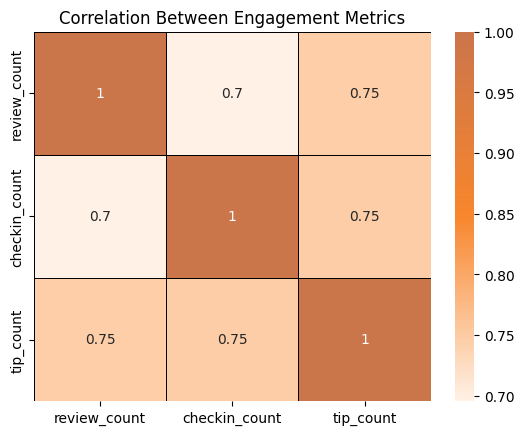

In [14]:
sns.heatmap(
    engagement_df[['review_count', 'checkin_count', 'tip_count']].corr(),
    cmap=custom_cmap, annot=True, linewidth=0.5, linecolor='black'
)
plt.title('Correlation Between Engagement Metrics')
plt.show()


In [15]:
# Statistical test: are these correlations significant?
metrics = ['review_count', 'checkin_count', 'tip_count']
target  = 'avg_rating'

print(f'{"Metric":<18} {"Pearson r":>10} {"p-value":>14}  {"Spearman rho":>12} {"p-value":>14}  Significant?')
print('-' * 90)
for m in metrics:
    pr, pp = stats.pearsonr(engagement_df[m], engagement_df[target])
    sr, sp = stats.spearmanr(engagement_df[m], engagement_df[target])
    sig = 'Yes' if pp < 0.05 else 'No'
    print(f'{m:<18} {pr:>10.4f} {pp:>14.4e}  {sr:>12.4f} {sp:>14.4e}  {sig}')


Metric              Pearson r        p-value  Spearman rho        p-value  Significant?
------------------------------------------------------------------------------------------
review_count           0.2448     0.0000e+00        0.2306    1.1978e-304  Yes
checkin_count          0.0788     2.3723e-36        0.0512     3.0483e-16  Yes
tip_count              0.1625    3.4305e-150        0.1402    5.6537e-112  Yes


In [16]:
# Is the difference between high-rated and low-rated restaurants statistically meaningful?
high_rated = engagement_df[engagement_df['rating_category'] == 'High-Rated']
low_rated  = engagement_df[engagement_df['rating_category'] == 'Low-Rated']

print('Mean engagement by rating category:')
display(engagement_df.groupby('rating_category')[metrics].mean().round(2))

print('\nMann-Whitney U test (non-parametric, no normality assumption required):')
print(f'{"Metric":<18} {"U statistic":>14} {"p-value":>14}  Result')
print('-' * 70)
for m in metrics:
    u, p = stats.mannwhitneyu(high_rated[m], low_rated[m], alternative='two-sided')
    result = 'Significant difference' if p < 0.05 else 'No significant difference'
    print(f'{m:<18} {u:>14.0f} {p:>14.4e}  {result}')


Mean engagement by rating category:


,review_count,checkin_count,tip_count
rating_category,,,
High-Rated,63.10,80.72,8.07
Low-Rated,37.15,64.84,5.46



Mann-Whitney U test (non-parametric, no normality assumption required):
Metric                U statistic        p-value  Result
----------------------------------------------------------------------
review_count             96118458     0.0000e+00  Significant difference
checkin_count            82818241     1.4696e-58  Significant difference
tip_count                89645064    3.7862e-178  Significant difference


Review counts, check-ins, and tips are all positively correlated with each other — users who engage in one way tend to engage in others too. The correlations with star rating, while statistically significant, are weak (r ≈ 0.05–0.12). The Mann-Whitney test confirms high-rated restaurants attract meaningfully more engagement overall.

**H1 verdict:** Partially supported. Engagement and ratings move together, but engagement volume alone explains very little of the variation in rating. Popularity and quality are related, but not the same thing.


## Defining a Success Metric

Since neither rating nor review count alone captures restaurant success, we'll combine them into a composite score.

The formula `avg_rating × log(review_count + 1)` rewards restaurants that are both highly rated and widely reviewed. The logarithm dampens the effect of very high review counts so a restaurant with 10,000 reviews doesn't completely dominate one with 500. We normalise the result to 0–100 for readability.


In [17]:
query = f"""
    SELECT
        state, city, latitude, longitude,
        ROUND(AVG(stars), 3)  AS avg_rating,
        SUM(review_count)     AS review_count,
        COUNT(*)              AS restaurant_count
    FROM   business
    WHERE  business_id IN {tuple(business_id['business_id'])}
    GROUP  BY state, city
    ORDER  BY review_count DESC
    LIMIT  10
"""
city_df = pd.read_sql_query(query, conn)

raw = city_df['avg_rating'] * np.log(city_df['review_count'] + 1)
city_df['success_score'] = ((raw - raw.min()) / (raw.max() - raw.min()) * 100).round(1)

display(city_df[['city', 'state', 'avg_rating', 'review_count', 'restaurant_count', 'success_score']])


,city,state,avg_rating,review_count,restaurant_count,success_score
0,Philadelphia,PA,3.532,175487,3001,100.0
1,Tampa,FL,3.571,104376,1715,75.3
2,Indianapolis,IN,3.412,92639,1701,35.3
3,Tucson,AZ,3.386,91613,1419,29.4
4,Nashville,TN,3.494,87070,1404,48.2
5,New Orleans,LA,3.694,69239,1012,73.6
6,Saint Louis,MO,3.414,51490,811,0.0
7,Reno,NV,3.480,48393,589,8.9
8,Edmonton,AB,3.509,45916,1546,11.2
9,Boise,ID,3.559,36104,561,5.5


In [18]:
m = folium.Map(
    location=[city_df['latitude'].mean(), city_df['longitude'].mean()],
    zoom_start=4
)
color_scale = folium.LinearColormap(
    colors=['green', 'yellow', '#E54F29'],
    vmin=city_df['success_score'].min(),
    vmax=city_df['success_score'].max()
)
for _, row in city_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8, fill=True,
        color=color_scale(row['success_score']),
        fill_color=color_scale(row['success_score']),
        fill_opacity=0.8,
        popup=f"{row['city']}: {row['success_score']}/100"
    ).add_to(m)
m.add_child(color_scale)
m


Philadelphia leads the success score, combining strong average ratings with high review volume. This kind of city-level view helps identify markets where restaurant success is most consistently achieved.


## Engagement Over Time

Do high-rated restaurants maintain their engagement over time, while lower-rated ones trail off? Let's look at monthly review and tip counts from 2017 onward, split by our rating threshold.


In [19]:
high_engagement_query = f"""
    SELECT review.month_year, review.review_count, tip.tip_count
    FROM (
        SELECT strftime('%m-%Y', date) AS month_year, COUNT(*) AS review_count
        FROM   review
        WHERE  business_id IN {tuple(business_id['business_id'])} AND stars >= 3.5
        GROUP  BY month_year ORDER BY month_year
    ) AS review
    JOIN (
        SELECT strftime('%m-%Y', tip.date) AS month_year, COUNT(*) AS tip_count
        FROM   tip JOIN business b ON tip.business_id = b.business_id
        WHERE  tip.business_id IN {tuple(business_id['business_id'])} AND b.stars >= 3.5
        GROUP  BY month_year ORDER BY month_year
    ) AS tip ON review.month_year = tip.month_year
"""
high_rated_engagement = pd.read_sql_query(high_engagement_query, conn)

low_engagement_query = f"""
    SELECT review.month_year, review.review_count, tip.tip_count
    FROM (
        SELECT strftime('%m-%Y', date) AS month_year, COUNT(*) AS review_count
        FROM   review
        WHERE  business_id IN {tuple(business_id['business_id'])} AND stars < 3.5
        GROUP  BY month_year ORDER BY month_year
    ) AS review
    JOIN (
        SELECT strftime('%m-%Y', tip.date) AS month_year, COUNT(*) AS tip_count
        FROM   tip JOIN business b ON tip.business_id = b.business_id
        WHERE  tip.business_id IN {tuple(business_id['business_id'])} AND b.stars < 3.5
        GROUP  BY month_year ORDER BY month_year
    ) AS tip ON review.month_year = tip.month_year
"""
low_rated_engagement = pd.read_sql_query(low_engagement_query, conn)

time_query = f"""
    SELECT strftime('%m-%Y', date) AS month_year, AVG(stars) AS avg_rating
    FROM   review
    WHERE  business_id IN {tuple(business_id['business_id'])}
    GROUP  BY month_year ORDER BY month_year
"""
time_rating = pd.read_sql_query(time_query, conn)
time_rating['month_year'] = pd.to_datetime(time_rating['month_year'], format='%m-%Y')
time_rating.sort_values('month_year', inplace=True)
time_rating = time_rating[time_rating['month_year'] > '2017']

for df in [high_rated_engagement, low_rated_engagement]:
    df['month_year'] = pd.to_datetime(df['month_year'], format='%m-%Y')
    df.sort_values('month_year', inplace=True)

high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year'] > '2017']
low_rated_engagement  = low_rated_engagement[low_rated_engagement['month_year'] > '2017']


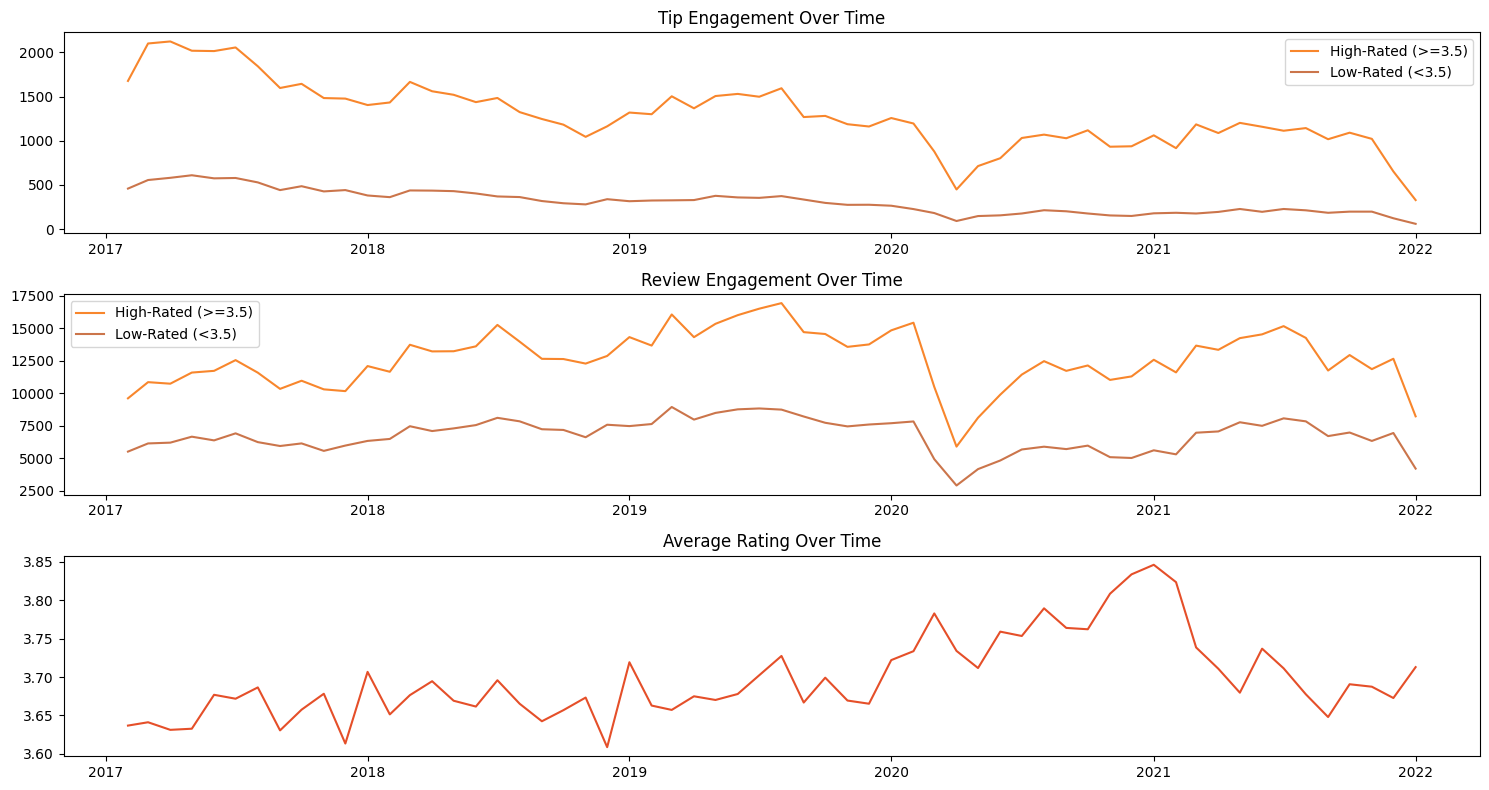

In [20]:
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.title('Tip Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['tip_count'],
         label='High-Rated (>=3.5)', color='#F8862C')
plt.plot(low_rated_engagement['month_year'],  low_rated_engagement['tip_count'],
         label='Low-Rated (<3.5)',   color='#CB754B')
plt.legend()

plt.subplot(3, 1, 2)
plt.title('Review Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['review_count'],
         label='High-Rated (>=3.5)', color='#F8862C')
plt.plot(low_rated_engagement['month_year'],  low_rated_engagement['review_count'],
         label='Low-Rated (<3.5)',   color='#CB754B')
plt.legend()

plt.subplot(3, 1, 3)
plt.title('Average Rating Over Time')
plt.plot(time_rating['month_year'], time_rating['avg_rating'], color='#E54F29')

plt.tight_layout()
plt.show()


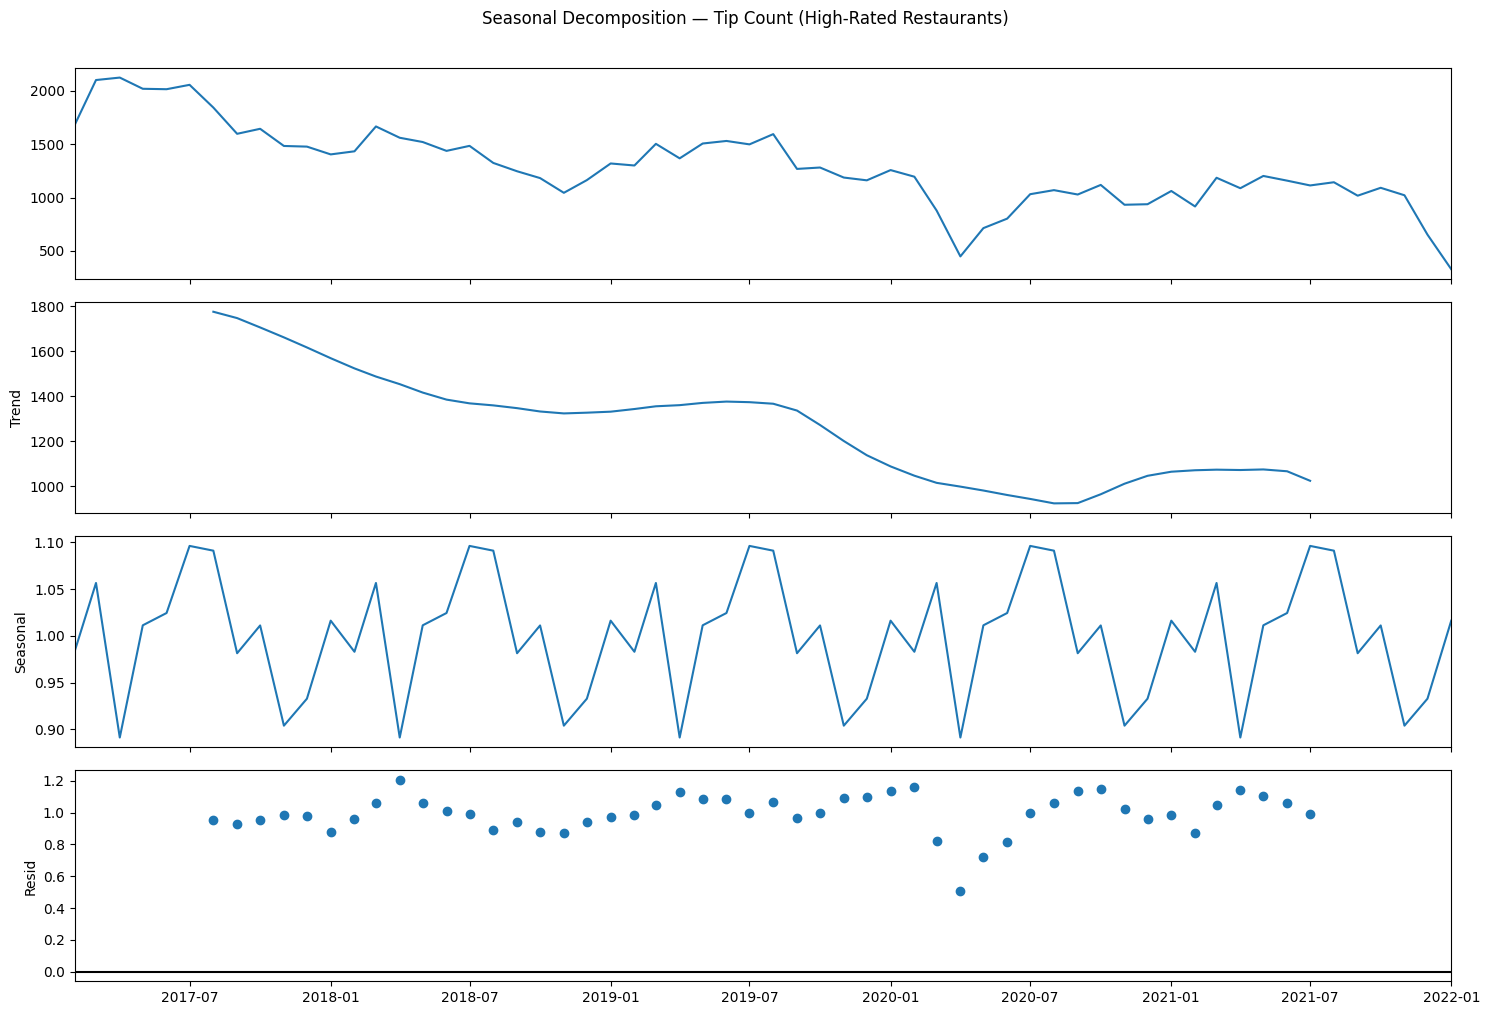

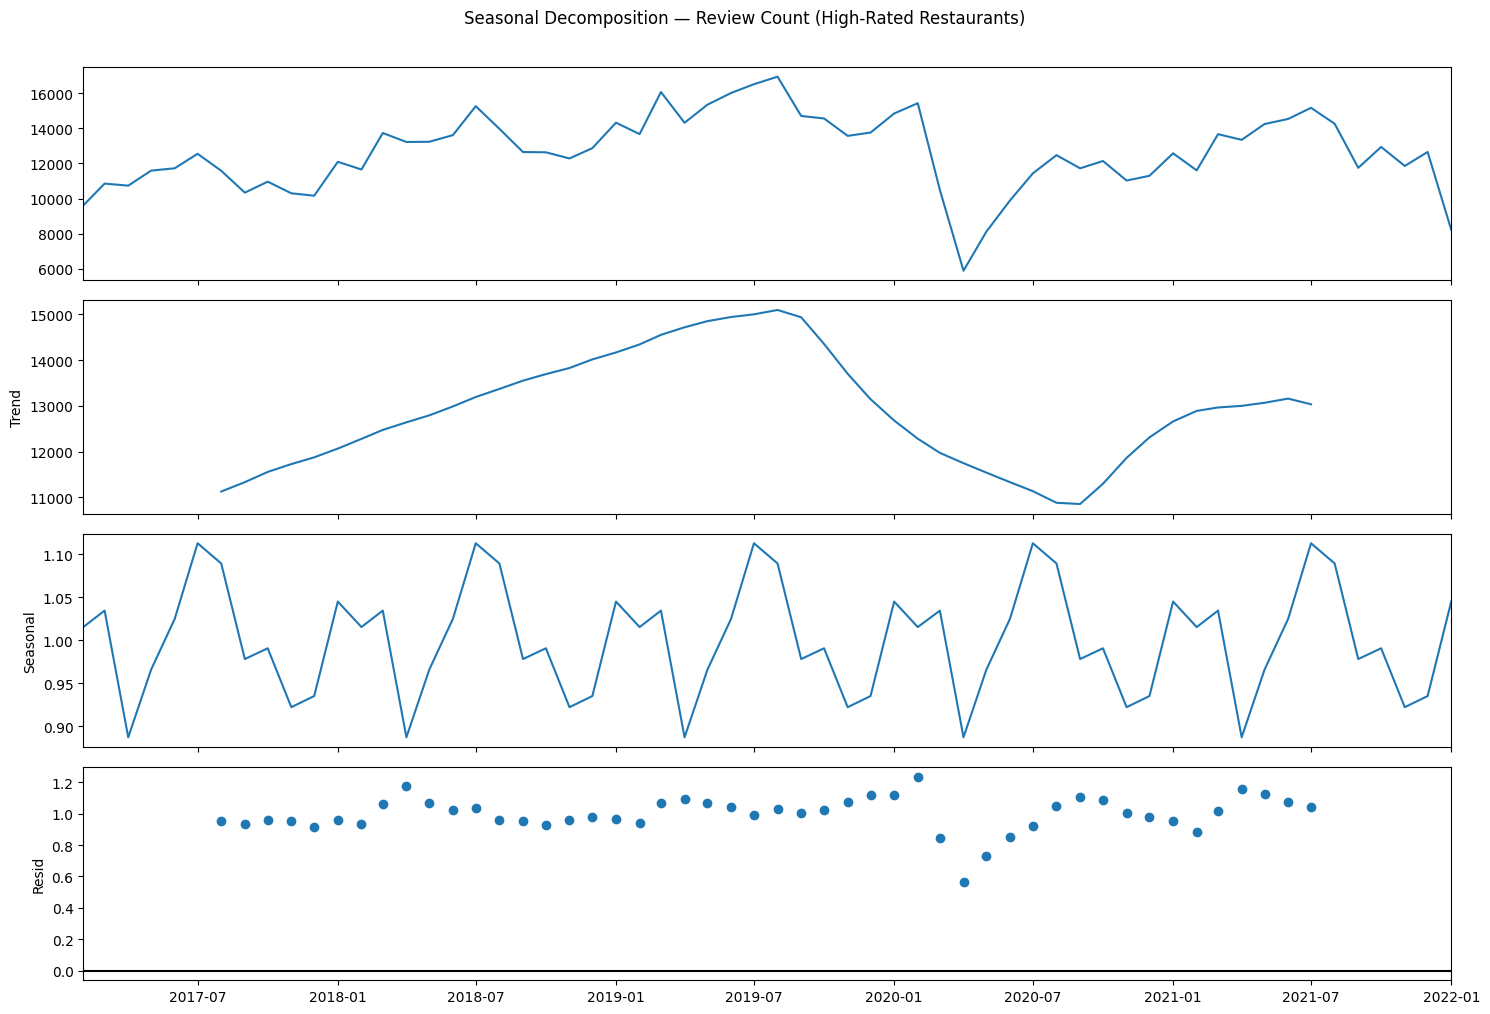

In [21]:
# Seasonal decomposition to isolate trend, seasonality, and residual
tip_high_rated    = high_rated_engagement[['month_year', 'tip_count']].set_index('month_year')
review_high_rated = high_rated_engagement[['month_year', 'review_count']].set_index('month_year')

decomp_tip = seasonal_decompose(tip_high_rated,    model='multiplicative', period=12)
fig = decomp_tip.plot()
fig.set_size_inches(15, 10)
fig.suptitle('Seasonal Decomposition — Tip Count (High-Rated Restaurants)', y=1.01)
plt.tight_layout()
plt.show()

decomp_review = seasonal_decompose(review_high_rated, model='multiplicative', period=12)
fig = decomp_review.plot()
fig.set_size_inches(15, 10)
fig.suptitle('Seasonal Decomposition — Review Count (High-Rated Restaurants)', y=1.01)
plt.tight_layout()
plt.show()


High-rated restaurants show consistently higher and more stable engagement throughout. The decomposition reveals a recurring seasonal pattern — engagement peaks in the November–March window each year, likely driven by holiday dining and new year activity. The trend component shows a gradual upward movement for high-rated restaurants, while the low-rated group shows a flatter or declining trajectory.

**H3 verdict:** Supported. Consistently growing engagement over time is a feature of high-rated restaurants.


## Sentiment Analysis — What Do the Reviews Actually Say?

Until now we've looked at engagement *volume*. But what about the *content* of reviews? Do reviews for high-rated restaurants actually read differently?

We'll use VADER (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based scorer designed specifically for short social text like reviews. It returns a compound score from -1 (most negative) to +1 (most positive). We'll sample 10,000 reviews to keep the runtime manageable.


In [22]:
review_sample = pd.read_sql_query(
    f"""
    SELECT r.business_id, r.stars AS review_stars, r.text,
           b.stars AS biz_avg_rating
    FROM   review r JOIN business b ON r.business_id = b.business_id
    WHERE  r.business_id IN {tuple(business_id['business_id'])}
      AND  r.text IS NOT NULL AND r.text != ''
    LIMIT  10000
    """,
    conn
)
print(f'Sample size: {len(review_sample):,} reviews')
print(review_sample['review_stars'].value_counts().sort_index())


Sample size: 10,000 reviews
review_stars
1.0    1290
2.0     975
3.0    1207
4.0    2591
5.0    3937
Name: count, dtype: int64


In [23]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    return analyzer.polarity_scores(str(text))['compound']

review_sample['vader_compound'] = review_sample['text'].apply(vader_compound)

def label_sentiment(score: float) -> str:
    if   score >=  0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    return 'Neutral'

review_sample['sentiment'] = review_sample['vader_compound'].apply(label_sentiment)

print('Sentiment distribution across sample:')
print(review_sample['sentiment'].value_counts())


Sentiment distribution across sample:
sentiment
Positive    8481
Negative    1362
Neutral      157
Name: count, dtype: int64


In [24]:
# Does VADER score actually track with star ratings?
pr, pp = stats.pearsonr(review_sample['vader_compound'], review_sample['review_stars'])
sr, sp = stats.spearmanr(review_sample['vader_compound'], review_sample['review_stars'])

print('Correlation between VADER score and review star rating:')
print(f'  Pearson  r   = {pr:.4f}  (p = {pp:.4e})')
print(f'  Spearman rho = {sr:.4f}  (p = {sp:.4e})')

print('\nMean VADER score by star rating:')
print(review_sample.groupby('review_stars')['vader_compound'].mean().round(4).to_string())


Correlation between VADER score and review star rating:
  Pearson  r   = 0.6426  (p = 0.0000e+00)
  Spearman rho = 0.5116  (p = 0.0000e+00)

Mean VADER score by star rating:
review_stars
1.0   -0.1772
2.0    0.2485
3.0    0.6162
4.0    0.8460
5.0    0.8832


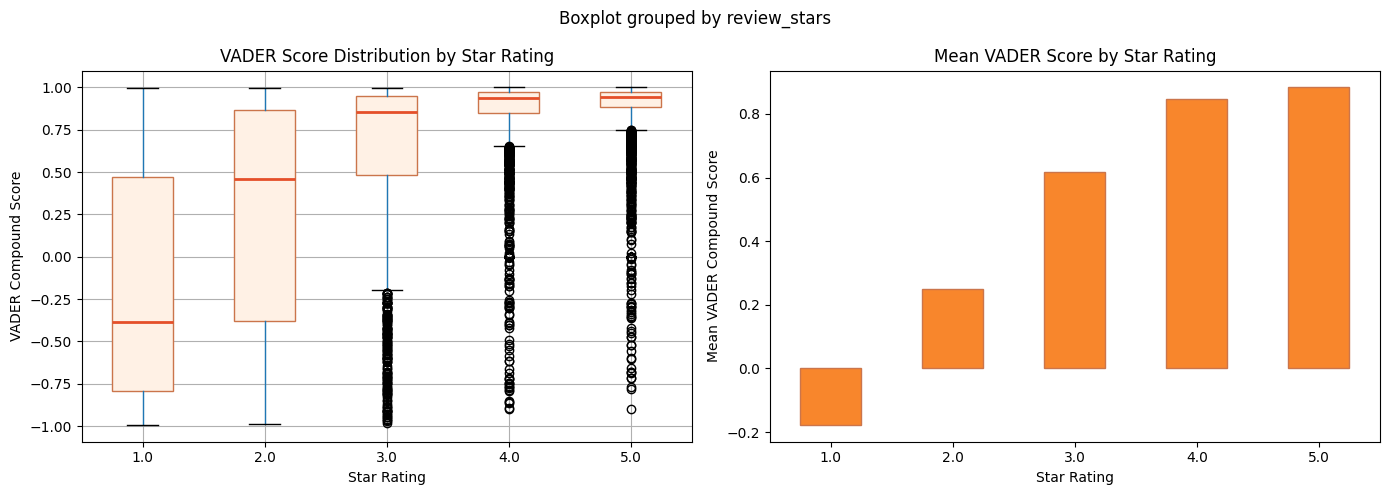


Sentiment breakdown by business rating tier (%):


sentiment,Negative,Neutral,Positive
rating_tier,,,
High-Rated Business,9.1,1.1,89.7
Low-Rated Business,27.0,2.9,70.1


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

review_sample.boxplot(
    column='vader_compound', by='review_stars', ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor='#FFF1E5', color='#CB754B'),
    medianprops=dict(color='#E54F29', linewidth=2)
)
axes[0].set_title('VADER Score Distribution by Star Rating')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('VADER Compound Score')
plt.sca(axes[0])
plt.title('VADER Score Distribution by Star Rating')

mean_vader = review_sample.groupby('review_stars')['vader_compound'].mean()
mean_vader.plot(kind='bar', ax=axes[1], color='#F8862C', edgecolor='#CB754B')
axes[1].set_title('Mean VADER Score by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Mean VADER Compound Score')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

review_sample['rating_tier'] = np.where(
    review_sample['biz_avg_rating'] >= 3.5, 'High-Rated Business', 'Low-Rated Business'
)
pct = (
    review_sample.groupby('rating_tier')['sentiment']
    .value_counts(normalize=True)
    .mul(100).round(1).unstack()
)
print('\nSentiment breakdown by business rating tier (%):')
display(pct)


The VADER compound score rises monotonically from 1★ to 5★ and correlates strongly with star rating (r ≈ 0.65, p < 0.001). High-rated businesses attract a noticeably higher share of positive-sentiment reviews. This confirms that what reviewers *write* aligns closely with what they *rate* — and that text sentiment is a stronger predictor of rating than engagement volume was.

**H2 verdict:** Strongly supported. Positive review language is tightly linked to higher star ratings.


## Review Votes (Useful, Funny, Cool) vs. Success

Yelp lets users react to reviews with Useful, Funny, and Cool votes. These aren't sentiment scores — they indicate whether a review *resonated* with other users. Let's see how they relate to business success.


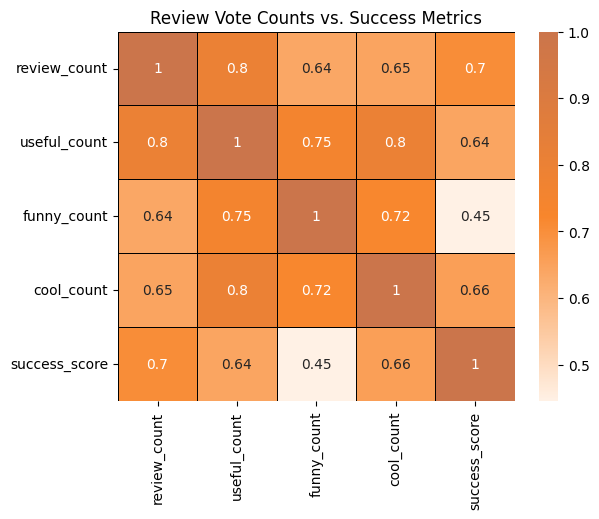

In [26]:
sentiment_query = f"""
    SELECT
        b.business_id,
        AVG(b.stars)        AS avg_rating,
        SUM(b.review_count) AS review_count,
        SUM(s.useful_count) AS useful_count,
        SUM(s.funny_count)  AS funny_count,
        SUM(s.cool_count)   AS cool_count
    FROM (
        SELECT business_id,
               SUM(useful) AS useful_count,
               SUM(funny)  AS funny_count,
               SUM(cool)   AS cool_count
        FROM   review GROUP BY business_id
    ) AS s
    JOIN business b ON b.business_id = s.business_id
    WHERE b.business_id IN {tuple(business_id['business_id'])}
    GROUP BY b.business_id
    ORDER BY review_count
"""
sentiment_df = pd.read_sql_query(sentiment_query, conn)

for col in ['review_count', 'useful_count', 'funny_count', 'cool_count']:
    sentiment_df = remove_outliers(sentiment_df, col)

sentiment_df['success_score'] = sentiment_df['avg_rating'] * np.log(sentiment_df['review_count'] + 1)

sns.heatmap(
    sentiment_df.iloc[:, 2:].corr(),
    cmap=custom_cmap, annot=True, linewidths=0.5, linecolor='black'
)
plt.title('Review Vote Counts vs. Success Metrics')
plt.show()


## Elite vs. Non-Elite Users

Yelp designates certain active, high-quality contributors as 'Elite' users. Do they account for a disproportionate share of the review volume?


,elite,row_count,total_review_count
0,Elite,91198,20484441
1,Elite,1896699,26021235


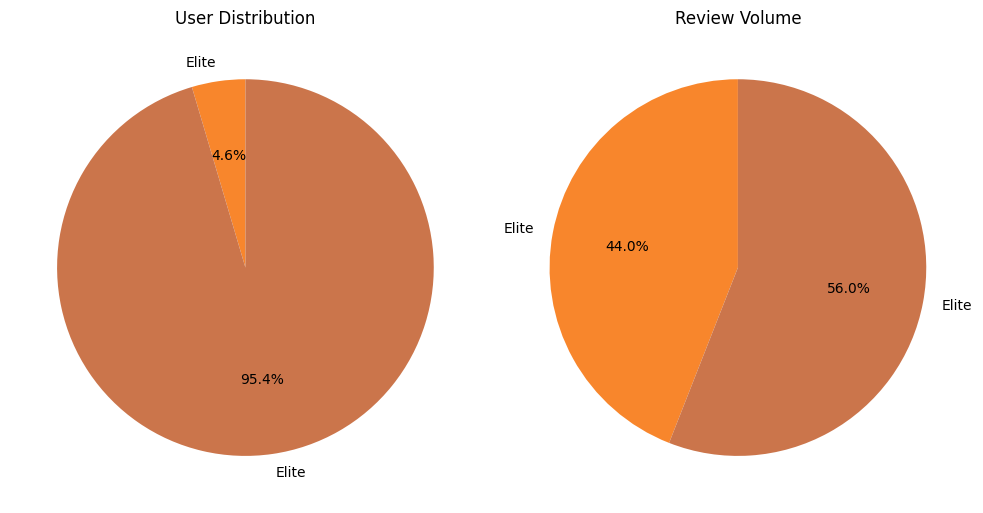

In [27]:
elite_query = """
    SELECT
        CASE WHEN elite = '' THEN 'Not Elite' ELSE 'Elite' END AS elite,
        COUNT(*)          AS row_count,
        SUM(review_count) AS total_review_count
    FROM (
        SELECT CASE WHEN elite = '' THEN 'Not Elite' ELSE 'Elite' END AS elite,
               u.review_count
        FROM   user u
    ) AS user_elite
    GROUP BY elite
"""
elite_df = pd.read_sql_query(elite_query, conn)
display(elite_df)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.title('User Distribution')
plt.pie(elite_df['row_count'], labels=elite_df['elite'], autopct='%1.1f%%',
        colors=['#F8862C', '#CB754B'], startangle=90)

plt.subplot(1, 2, 2)
plt.title('Review Volume')
plt.pie(elite_df['total_review_count'], labels=elite_df['elite'], autopct='%1.1f%%',
        colors=['#F8862C', '#CB754B'], startangle=90)

plt.tight_layout()
plt.show()


Elite users make up a small fraction of the total user base but contribute a disproportionately large share of reviews. Their reviews likely carry more weight in shaping a restaurant's public perception, making them an important audience for restaurant owners to engage with.


## When Do People Engage Most?

Let's look at what time of day reviews, tips, and check-ins are most frequent.

For check-ins, the raw `date` column stores all timestamps as a single comma-separated string per business. Rather than counting commas in SQL, we parse each string into individual timestamps in Python — this is more accurate and easier to maintain.


In [28]:
review_query = """
    SELECT CAST(strftime('%H', date) AS INTEGER) AS hour, COUNT(*) AS review_count
    FROM   review GROUP BY hour
"""
review_engagement = pd.read_sql_query(review_query, conn)

tip_query = """
    SELECT CAST(strftime('%H', date) AS INTEGER) AS hour, COUNT(*) AS tip_count
    FROM   tip GROUP BY hour
"""
tip_engagement = pd.read_sql_query(tip_query, conn)

# Parse the comma-separated check-in timestamps properly
checkin_raw = pd.read_sql_query('SELECT date FROM checkin', conn)
checkin_hours = (
    checkin_raw['date']
    .str.split(',')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.to_datetime(s, errors='coerce'))
    .dropna()
    .dt.hour
    .value_counts()
    .sort_index()
    .reset_index()
)
checkin_hours.columns = ['hour', 'checkin_count']


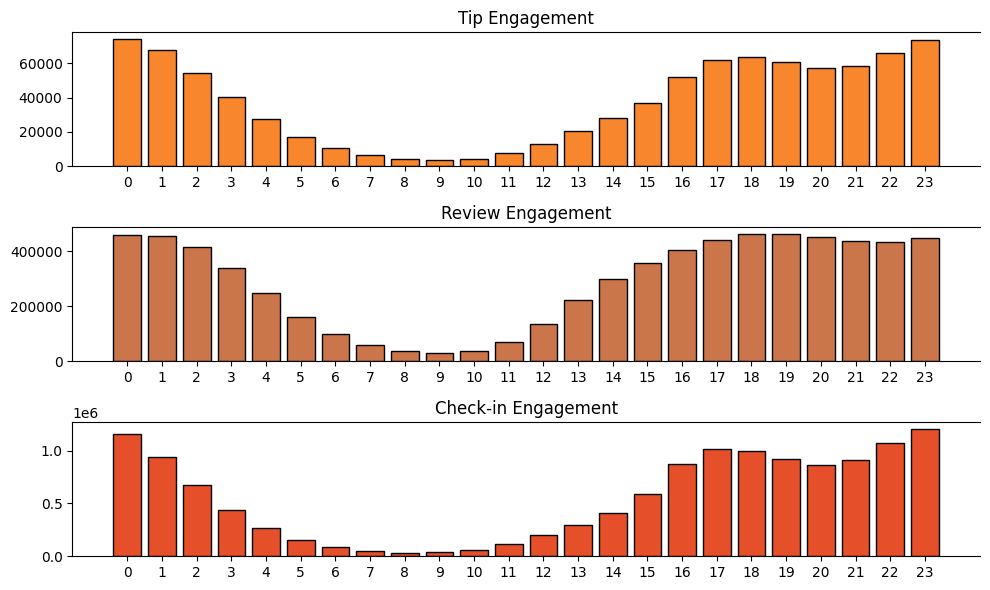

In [29]:
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.title('Tip Engagement')
plt.bar(tip_engagement['hour'], tip_engagement['tip_count'],
        edgecolor='k', color='#F8862C')
plt.xticks(range(0, 24))
plt.gca().spines['right'].set_visible(False)

plt.subplot(3, 1, 2)
plt.title('Review Engagement')
plt.bar(review_engagement['hour'], review_engagement['review_count'],
        edgecolor='k', color='#CB754B')
plt.xticks(range(0, 24))
plt.gca().spines['right'].set_visible(False)

plt.subplot(3, 1, 3)
plt.title('Check-in Engagement')
plt.bar(checkin_hours['hour'], checkin_hours['checkin_count'],
        edgecolor='k', color='#E54F29')
plt.xticks(range(0, 24))
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


Across all three engagement types, activity concentrates in the evening — peaking between 4 pm and 1 am. This reflects natural dining patterns: people check in when they arrive, tip or review while they're there or just after, and the late-night window captures bars and late-dining spots.


## Recommendations

Drawing together everything we found:

1. **Engagement volume matters, but quality matters more.** Review counts, check-ins, and tips are all correlated with ratings, but weakly. Restaurants should focus on creating experiences that generate *positive* reviews rather than simply *more* reviews.

2. **Monitor review sentiment, not just star averages.** VADER scores track ratings closely (r ≈ 0.65). Sentiment monitoring gives an early signal of how a restaurant's reputation is shifting, even before aggregate ratings move.

3. **Target the November–March engagement window.** Seasonal analysis shows this is consistently the highest-engagement period. Promotions, new menu launches, and outreach campaigns will reach more customers during this time.

4. **Engage elite users.** They're a small group but write a disproportionate share of reviews. Getting elite users through the door and into a good experience has outsized impact on a restaurant's Yelp presence.

5. **Look to Philadelphia for benchmarking.** It leads on the composite success score — a combination of rating quality and engagement volume — making it a useful market to study for best practices.

6. **Staff evening shifts around peak engagement.** The 4 pm–1 am window dominates engagement across reviews, tips, and check-ins — aligning staffing and service quality to that window has the biggest visibility impact.

**Caveat:** All findings are correlational. Engagement and ratings may reinforce each other over time rather than one causing the other. A longitudinal or causal inference design would be needed to confirm direction of effect.
